# Project Guide: Diffusion for Path Mask Generation (Teacher Advice → Actionable Checklist)

## Goal
Build a **2D image diffusion model** that generates a path mask from:
- occupancy map
- start location
- goal location

Then post-process the generated mask into one valid path from start to goal.

---

## Step 0 — Choose path-mask definition
Use one of the following targets (default: **A + optional softening**):

- **A) Binary mask (recommended baseline)**
  - Path pixels = 1, others = 0
  - Easiest to implement/debug

- **B) Soft mask (Gaussian brush, recommended for smoother learning)**
  - Convert path waypoints into Gaussian blobs
  - Range in [0, 1]
  - Usually gives more stable/continuous generations

**Current decision for this notebook:** `TODO: binary / soft / hybrid`

---

## Step 1 — Build 3-channel conditioning `cond`
For each map, create:

1. **Occupancy channel**
   - Input grid: `0=free, 1=obstacle`
   - Keep as `0/1`
   - Shape: `[1, 64, 64]`

2. **Start heatmap channel**
   - Use Gaussian blob centered at start cell (not single pixel)
   - Suggested `sigma = 1~2` pixels, amplitude `1.0`
   - Shape: `[1, 64, 64]`

3. **Goal heatmap channel**
   - Same construction as start heatmap
   - Shape: `[1, 64, 64]`

Concatenate:

`cond = torch.cat([occ, start_hm, goal_hm], dim=0)  # [3,64,64]`

**Why heatmap > single point:** less sparse, easier for CNN to learn global direction.

---

## Step 2 — Build training target `x0` = path mask
Target shape/value:
- `x0` shape: `[1, 64, 64]`
- Value range: `[0,1]`

Two ways to create target:

- **2.1 From A* discrete path (baseline)**
  - For each path cell `(row, col)`: set `mask[row, col] = 1`

- **2.2 From smooth_path continuous coordinates (preferred)**
  - Rasterize each waypoint `(r, c)` by:
    - nearest cell (`round`) OR
    - Gaussian brush (preferred)

**Current decision for this notebook:** `TODO: A* binary / smooth Gaussian`

---

## Step 3 — Switch diffusion from trajectory to image DDPM
Use image-based setup:

- `x0`: `[B,1,64,64]`
- `cond`: `[B,3,64,64]`
- `noise`: same shape as `x0`

Forward process:

`x_t = sqrt(alpha_bar_t) * x0 + sqrt(1 - alpha_bar_t) * noise`

Model:
- 2D U-Net
- Input by channel concat:
  - `model_input = torch.cat([x_t, cond], dim=1)  # [B,4,64,64]`
- Output predicts `epsilon` with shape `[B,1,64,64]`

Loss:
- `MSE(eps_pred, eps_true)`
- Do **not** add end/smooth/collision penalties initially

---

## Step 4 — Sampling output to path probability mask
After reverse diffusion:
- `x0_gen` shape `[1,64,64]` (continuous values)

Binarize:
- `mask_bin = (x0_gen > thr)`
- Sweep `thr` in `0.3 ~ 0.6`

Optional denoise:
- keep largest connected component

**Current threshold plan:** `TODO: fixed / sweep / Otsu`

---

## Step 5 — Skeletonize thick mask into 1-pixel centerline
Use `skimage.morphology.skeletonize`:

1. Convert to bool
2. (Optional) `binary_closing` or small dilation if broken
3. Apply `skeletonize`

If skeleton is disconnected, try mild morphology before skeletonization.

---

## Step 6 — Extract one path from start to goal on skeleton
Skeleton may branch. Preferred method:

- Build graph from skeleton pixels (8-neighbor)
- Find skeleton pixel nearest to start
- Find skeleton pixel nearest to goal
- Run shortest path (BFS/Dijkstra) on skeleton graph

Output = ordered pixel sequence (one valid path).

---

## Step 7 — Convert path back to your plotting format
Your plotting uses:
- `plt.plot(path[:,1], path[:,0])`  (col as x, row as y)

So final exported path should be list/array of `(row, col)`.

If fixed length is needed (e.g., 128 points):
- arc-length interpolation resample, or
- spline then sample 128 points

---

## Step 8 — Common failure modes + checks
1. **Looks like a path but not connected to start/goal**
   - Use start/goal Gaussian heatmaps
   - Force graph search from start-nearest to goal-nearest skeleton nodes

2. **Path crosses obstacles**
   - Ensure GT target only on free cells
   - Keep occupancy channel accurate
   - Post-process: remove skeleton pixels on obstacles, then re-search path

3. **Threshold sensitivity**
   - Sweep threshold
   - Try Otsu
   - Optional regularization only if necessary

---

## Minimal Implementation Order (Do This First)
1. Build dataset with `cond=[occ,start_hm,goal_hm]` and binary `x0` from A*
2. Train image DDPM with U-Net (`input=4ch`, `output=1ch`, MSE noise loss)
3. Sample + threshold
4. Skeletonize
5. Graph shortest-path extraction start→goal
6. Evaluate connectivity + collision rate

---

## Editable Hyperparameter Block
- `MAP_SIZE = 64`
- `START_GOAL_SIGMA = TODO`  (suggest 1~2)
- `PATH_BRUSH_SIGMA = TODO`  (if soft target)
- `THRESHOLD = TODO`  (or sweep 0.3~0.6)
- `USE_LARGEST_CC = TODO`  (`True/False`)
- `SKELETON_PRE_CLOSING = TODO`  (`0/1/2` iterations)
- `PATH_LENGTH = 128`  (if fixed-length output needed)

---

## Acceptance Criteria (for report)
- Generated path connects start to goal
- No obstacle collision (or collision rate reported)
- Path extraction succeeds robustly on branchy skeletons
- Visual result is continuous and interpretable
- Metrics reported over test set (success rate, avg path length, collision rate)


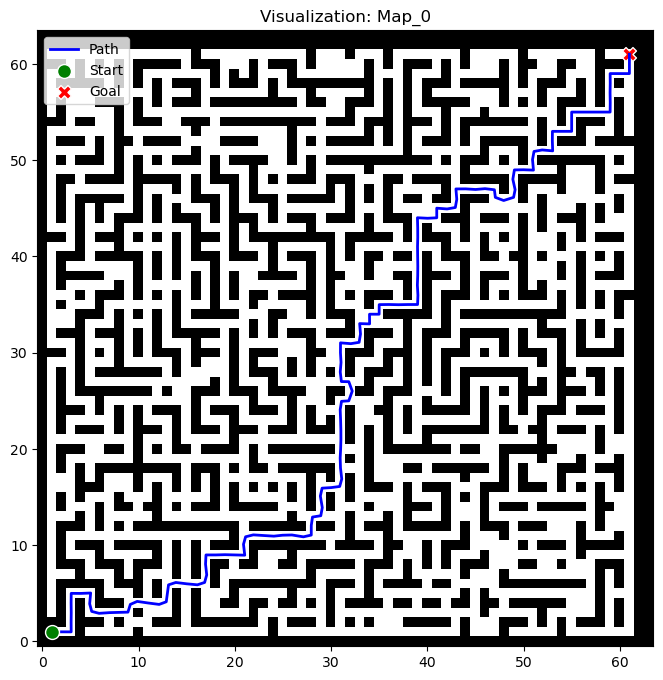

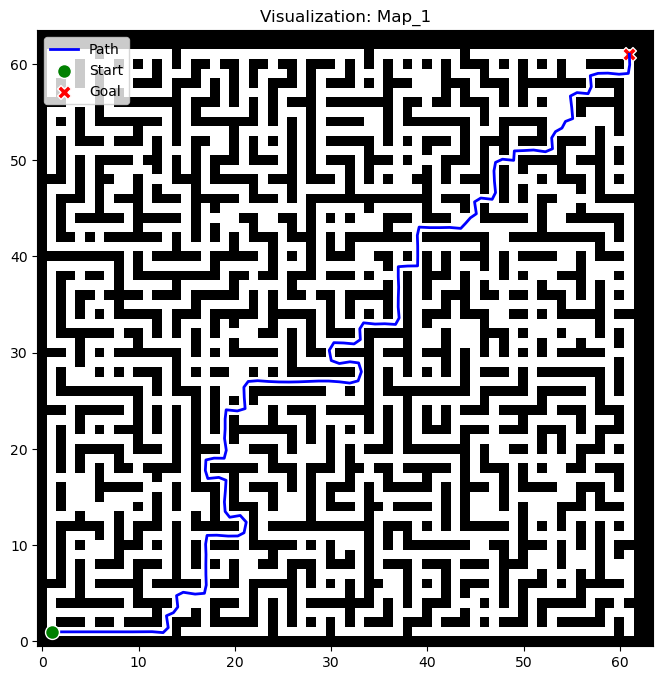

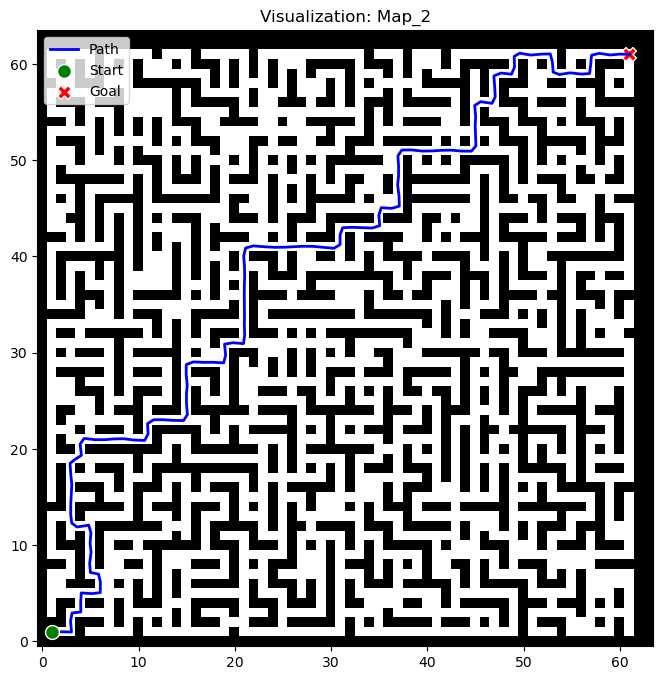

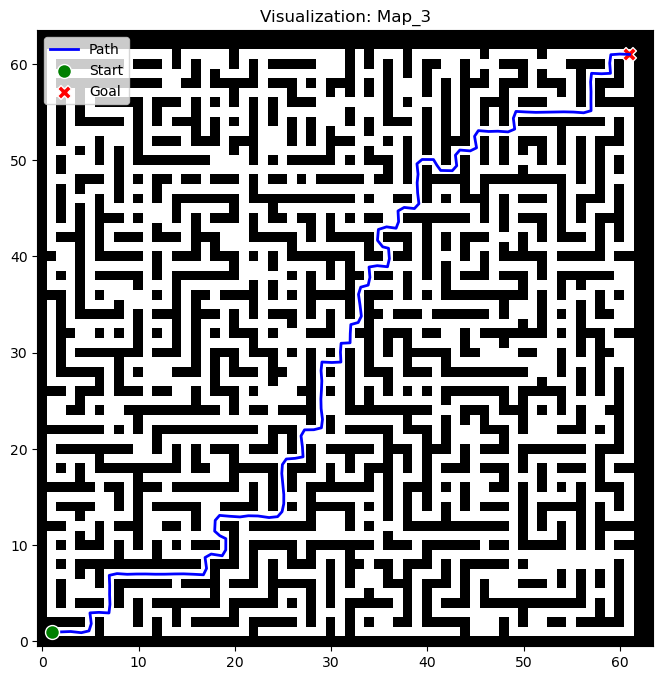

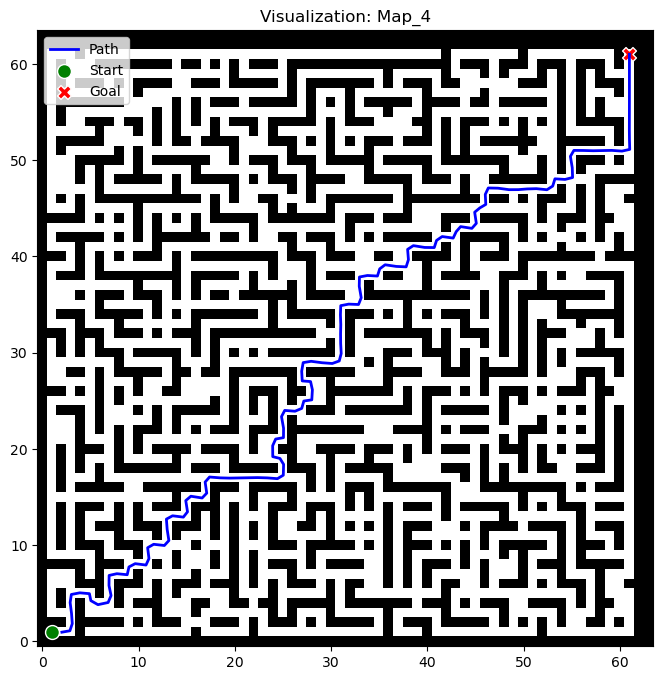

Done. Visualized first 5 maps and stored all 2000 maps in map_dictionary.


In [1]:
import random
import heapq
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import splprep, splev

def B_spline(a_star_path, s=0.0, k=3, num_points=100):
    path = np.array(a_star_path)
    x = path[:, 0]
    y = path[:, 1]

    tck, _ = splprep([x, y], s=s, k=k)

    u_fine = np.linspace(0, 1, num_points)
    x_smooth, y_smooth = splev(u_fine, tck)

    return np.vstack((x_smooth, y_smooth)).T

# def generate_map(size=64, obstacle_prob=0.2):
#     # 0 = Free space, 1 = Obstacle
#     grid = np.zeros((size, size))

#     for i in range(size):
#         for j in range(size):
#             if random.random() < obstacle_prob:
#                 grid[i, j] = 1

#     def get_free_point():
#         while True:
#             x, y = random.randint(0, size - 1), random.randint(0, size - 1)
#             if grid[x, y] == 0:
#                 return (x, y)

#     start = get_free_point()

#     while True:
#         goal = get_free_point()
#         if goal != start and np.linalg.norm(np.array(goal) - np.array(start)) > 10:
#             break

#     return grid, start, goal

# In Cell 1, replace the old generate_map with this:
def generate_map(size=64, multiplier=1, loop_prob=0.2):
    # For multiplier = 1, we generate a maze on the largest odd size 
    # that fits (size - 1) to ensure the algorithm logic works.
    if multiplier == 1:
        effective_size = size - 1 
    else:
        effective_size = size // multiplier
        if effective_size % 2 == 0: effective_size -= 1

    # 1. Generate the Skeleton on the effective_size
    skeleton = np.ones((effective_size, effective_size))
    stack = [(1, 1)]
    skeleton[1, 1] = 0
    visited = {(1, 1)}

    while stack:
        x, y = stack[-1]
        neighbors = []
        for dx, dy in [(0, -2), (0, 2), (-2, 0), (2, 0)]:
            nx, ny = x + dx, y + dy
            if 0 < nx < effective_size-1 and 0 < ny < effective_size-1 and (nx, ny) not in visited:
                neighbors.append((nx, ny, x + dx//2, y + dy//2))
        if neighbors:
            nx, ny, wx, wy = random.choice(neighbors)
            skeleton[ny, nx] = 0
            skeleton[wy, wx] = 0
            visited.add((nx, ny))
            stack.append((nx, ny))
        else:
            stack.pop()

    # 2. Add Loops (Braiding)
    for y in range(1, effective_size - 1):
        for x in range(1, effective_size - 1):
            if skeleton[y, x] == 1:
                if (skeleton[y, x-1] == 0 and skeleton[y, x+1] == 0) or \
                   (skeleton[y-1, x] == 0 and skeleton[y+1, x] == 0):
                    if random.random() < loop_prob:
                        skeleton[y, x] = 0

    # 3. Create the final grid of exactly 'size'
    final_grid = np.ones((size, size))
    
    # Upscale and place into the final grid
    for r in range(effective_size):
        for c in range(effective_size):
            if skeleton[r, c] == 0:
                # This places the upscaled skeleton into the top-left of the final_grid
                final_grid[r*multiplier : (r+1)*multiplier, 
                           c*multiplier : (c+1)*multiplier] = 0

    # Set start and goal based on the generated skeleton area
    start = (multiplier, multiplier)
    goal = ((effective_size - 2) * multiplier, (effective_size - 2) * multiplier)
    
    return final_grid, start, goal

def a_star(grid, start, goal):
    size = grid.shape[0]
    neighbors = [(0, 1), (0, -1), (1, 0), (-1, 0)]

    close_set = set()
    came_from = {}
    gscore = {start: 0}
    fscore = {start: np.linalg.norm(np.array(start) - np.array(goal))}
    oheap = []

    heapq.heappush(oheap, (fscore[start], start))

    while oheap:
        current = heapq.heappop(oheap)[1]

        if current == goal:
            data = []
            while current in came_from:
                data.append(current)
                current = came_from[current]
            return data[::-1]

        close_set.add(current)
        for i, j in neighbors:
            neighbor = current[0] + i, current[1] + j
            move_cost = np.sqrt(i**2 + j**2)
            tentative_g_score = gscore[current] + move_cost

            if 0 <= neighbor[0] < size and 0 <= neighbor[1] < size:
                if grid[neighbor[0], neighbor[1]] == 1:
                    continue
            else:
                continue

            if neighbor in close_set and tentative_g_score >= gscore.get(neighbor, 0):
                continue

            if tentative_g_score < gscore.get(neighbor, 0) or neighbor not in [n[1] for n in oheap]:
                came_from[neighbor] = current
                gscore[neighbor] = tentative_g_score
                fscore[neighbor] = tentative_g_score + np.linalg.norm(np.array(neighbor) - np.array(goal))
                heapq.heappush(oheap, (fscore[neighbor], neighbor))

    return None

def visualize_path(map_data, start, goal, path=None, map_id="Map"):
    plt.figure(figsize=(8, 8))
    plt.imshow(map_data, cmap='Greys', origin='lower')

    if path is not None and len(path) > 0:
        path_np = np.array(path)
        plt.plot(path_np[:, 1], path_np[:, 0], color='blue', linewidth=2, label='Path')

    plt.scatter(start[1], start[0], c='green', s=100, label='Start', marker='o', edgecolors='white')
    plt.scatter(goal[1], goal[0], c='red', s=100, label='Goal', marker='X', edgecolors='white')

    plt.title(f"Visualization: {map_id}")
    plt.legend()
    plt.grid(False)
    plt.show()

MAP_SIZE = 64
MAP_NUM = 2000
PLOT_FIRST_N = 5

map_dictionary = {}

# Generate maps
for i in range(MAP_NUM):
    grid_map, start, goal = generate_map(size=MAP_SIZE)
    map_dictionary[f"Map_{i}"] = {
        "map": grid_map,
        "start": start,
        "goal": goal,
        "path": None,
        "smooth_path": None,
    }

# Run A* and B-spline smoothing; only visualize first 5 maps
for idx, (map_id, data) in enumerate(map_dictionary.items()):
    path = a_star(data['map'], data['start'], data['goal'])
    map_dictionary[map_id]['path'] = path

    if path is not None and len(path) >= 4:
        smooth_path = B_spline(path, s=1, k=3, num_points=128)
        map_dictionary[map_id]['smooth_path'] = smooth_path
    else:
        map_dictionary[map_id]['smooth_path'] = None

    if idx < PLOT_FIRST_N:
        path_to_show = map_dictionary[map_id]['smooth_path']
        if path_to_show is None:
            path_to_show = map_dictionary[map_id]['path']
        visualize_path(
            map_dictionary[map_id]['map'],
            map_dictionary[map_id]['start'],
            map_dictionary[map_id]['goal'],
            path_to_show,
            map_id,
        )

print(f"Done. Visualized first {PLOT_FIRST_N} maps and stored all {MAP_NUM} maps in map_dictionary.")

In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
from scipy.ndimage import distance_transform_edt
import numpy as np


def gaussian_heatmap(map_size, center, sigma=1.5):
    h, w = map_size
    cy, cx = float(center[0]), float(center[1])
    y = np.arange(h, dtype=np.float32)
    x = np.arange(w, dtype=np.float32)
    yy, xx = np.meshgrid(y, x, indexing='ij')
    heatmap = np.exp(-((yy - cy) ** 2 + (xx - cx) ** 2) / (2.0 * sigma * sigma))
    return heatmap.astype(np.float32)


def add_gaussian_brush(mask, r, c, sigma=1.2):
    h, w = mask.shape
    radius = int(np.ceil(3.0 * sigma))

    r0 = max(0, int(np.floor(r)) - radius)
    r1 = min(h - 1, int(np.floor(r)) + radius)
    c0 = max(0, int(np.floor(c)) - radius)
    c1 = min(w - 1, int(np.floor(c)) + radius)

    ys = np.arange(r0, r1 + 1, dtype=np.float32)
    xs = np.arange(c0, c1 + 1, dtype=np.float32)
    yy, xx = np.meshgrid(ys, xs, indexing='ij')

    patch = np.exp(-((yy - r) ** 2 + (xx - c) ** 2) / (2.0 * sigma * sigma)).astype(np.float32)
    mask[r0:r1 + 1, c0:c1 + 1] = np.maximum(mask[r0:r1 + 1, c0:c1 + 1], patch)


class PathPlanningDataset(Dataset):
    def __init__(
        self,
        map_dict,
        map_size=64,
        start_goal_sigma=1.5,
        path_sigma=1.2,
        output_mode='trajectory',  # 'trajectory' (legacy) or 'mask' (Step 0~2)
    ):
        self.map_size = map_size
        self.coord_scale = float(map_size - 1)
        self.start_goal_sigma = start_goal_sigma
        self.path_sigma = path_sigma
        self.output_mode = output_mode
        self.data_list = [v for _, v in map_dict.items() if v.get('smooth_path') is not None]

        # 預先計算每張地圖到最近障礙物的距離 (給 legacy trajectory pipeline 用)
        self.dist_maps = []
        for item in self.data_list:
            occ = item['map'].astype(np.float32)          # 0: free, 1: obstacle
            free_mask = (occ < 0.5).astype(np.uint8)      # free=1, obstacle=0
            dist_map = distance_transform_edt(free_mask).astype(np.float32)
            self.dist_maps.append(dist_map)

    def __len__(self):
        return len(self.data_list)

    def _build_cond(self, item):
        occ = item['map'].astype(np.float32)  # 0/1, shape [64,64]
        start_hm = gaussian_heatmap((self.map_size, self.map_size), item['start'], sigma=self.start_goal_sigma)
        goal_hm = gaussian_heatmap((self.map_size, self.map_size), item['goal'], sigma=self.start_goal_sigma)
        cond = np.stack([occ, start_hm, goal_hm], axis=0).astype(np.float32)  # [3,64,64]
        return cond

    def _build_soft_path_mask(self, item):
        # Step 0 + Step 2: soft mask + smooth_path continuous coordinates
        occ = item['map'].astype(np.float32)
        smooth_path = np.asarray(item['smooth_path'], dtype=np.float32)  # [N,2] as (row,col)
        smooth_path = np.clip(smooth_path, 0.0, self.coord_scale)

        mask = np.zeros((self.map_size, self.map_size), dtype=np.float32)
        for r, c in smooth_path:
            add_gaussian_brush(mask, float(r), float(c), sigma=self.path_sigma)

        # 保持值域 [0,1] 並避免畫到障礙物
        mask = np.clip(mask, 0.0, 1.0)
        mask = mask * (1.0 - occ)
        return mask.astype(np.float32)

    def __getitem__(self, idx):
        item = self.data_list[idx]

        # New mask pipeline (for image diffusion, Step 0~2)
        if self.output_mode == 'mask':
            cond = self._build_cond(item)                        # [3,64,64]
            path_mask = self._build_soft_path_mask(item)         # [64,64], soft in [0,1]
            cond_tensor = torch.from_numpy(cond)                 # [3,64,64]
            path_tensor = torch.from_numpy(path_mask).unsqueeze(0)  # [1,64,64]
            return path_tensor, cond_tensor

        # Legacy trajectory pipeline (kept for compatibility with existing training code)
        traj = item['smooth_path'].copy()  # [128, 2], (row, col)
        traj = np.clip(traj, 0.0, self.coord_scale)
        traj = (traj / self.coord_scale) * 2.0 - 1.0
        traj_tensor = torch.from_numpy(traj).float().permute(1, 0)  # [2, 128]

        map_arr = item['map'].astype(np.float32)
        map_arr = map_arr * 2.0 - 1.0
        map_tensor = torch.from_numpy(map_arr).unsqueeze(0)  # [1, 64, 64]

        start = item['start']
        goal = item['goal']
        goal_vals = torch.tensor([
            start[0] / self.coord_scale, start[1] / self.coord_scale,
            goal[0] / self.coord_scale, goal[1] / self.coord_scale,
        ]).float()
        goal_tensor = goal_vals * 2.0 - 1.0

        dist_tensor = torch.from_numpy(self.dist_maps[idx]).unsqueeze(0)  # [1, 64, 64]

        return traj_tensor, map_tensor, goal_tensor, dist_tensor


# 保留原本訓練流程用的 Dataset / DataLoader
legacy_dataset = PathPlanningDataset(map_dictionary, map_size=64, output_mode='trajectory')
train_loader = DataLoader(legacy_dataset, batch_size=32, shuffle=True)
print(f"Legacy trajectory dataset size: {len(legacy_dataset)}")

# 新增 Step 0~2 的影像 diffusion 訓練資料
mask_dataset = PathPlanningDataset(
    map_dictionary,
    map_size=64,
    start_goal_sigma=1.5,
    path_sigma=1.2,
    output_mode='mask',
)
mask_loader = DataLoader(mask_dataset, batch_size=32, shuffle=True)

sample_x0, sample_cond = mask_dataset[0]
print(f"Mask dataset size: {len(mask_dataset)}")
print(f"x0 (path mask) shape: {sample_x0.shape}, range=({sample_x0.min().item():.3f}, {sample_x0.max().item():.3f})")
print(f"cond shape: {sample_cond.shape}, occ range=({sample_cond[0].min().item():.1f}, {sample_cond[0].max().item():.1f})")

Legacy trajectory dataset size: 2000
Mask dataset size: 2000
x0 (path mask) shape: torch.Size([1, 64, 64]), range=(0.000, 1.000)
cond shape: torch.Size([3, 64, 64]), occ range=(0.0, 1.0)


In [3]:
!nvidia-smi

Wed Mar  4 01:38:06 2026       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.161.08             Driver Version: 535.161.08   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A30                     Off | 00000000:88:00.0 Off |                   On |
| N/A   35C    P0              55W / 165W |                  N/A |     N/A      Default |
|                                         |                      |              Enabled |
+-----------------------------------------+----------------------+--

Training on cuda, epochs=200
Epoch 000 | Loss: 0.282418
Epoch 010 | Loss: 0.030894
Epoch 020 | Loss: 0.015964
Epoch 030 | Loss: 0.010695
Epoch 040 | Loss: 0.011425
Epoch 050 | Loss: 0.010243
Epoch 060 | Loss: 0.006986
Epoch 070 | Loss: 0.006514
Epoch 080 | Loss: 0.007041
Epoch 090 | Loss: 0.005680
Epoch 100 | Loss: 0.005205
Epoch 110 | Loss: 0.005565
Epoch 120 | Loss: 0.005449
Epoch 130 | Loss: 0.003707
Epoch 140 | Loss: 0.005258
Epoch 150 | Loss: 0.003596
Epoch 160 | Loss: 0.003655
Epoch 170 | Loss: 0.004183
Epoch 180 | Loss: 0.003315
Epoch 190 | Loss: 0.003428
Step 4 selected threshold: 0.30 (IoU=0.0000, use_lcc=True)
Sweep scores: [(0.3, 0.0), (0.35, 0.0), (0.39999999999999997, 0.0), (0.44999999999999996, 0.0), (0.49999999999999994, 0.0), (0.5499999999999999, 0.0), (0.5999999999999999, 0.0)]
Step 6 path found: True
Raw path points: 61 | Resampled path points: 128


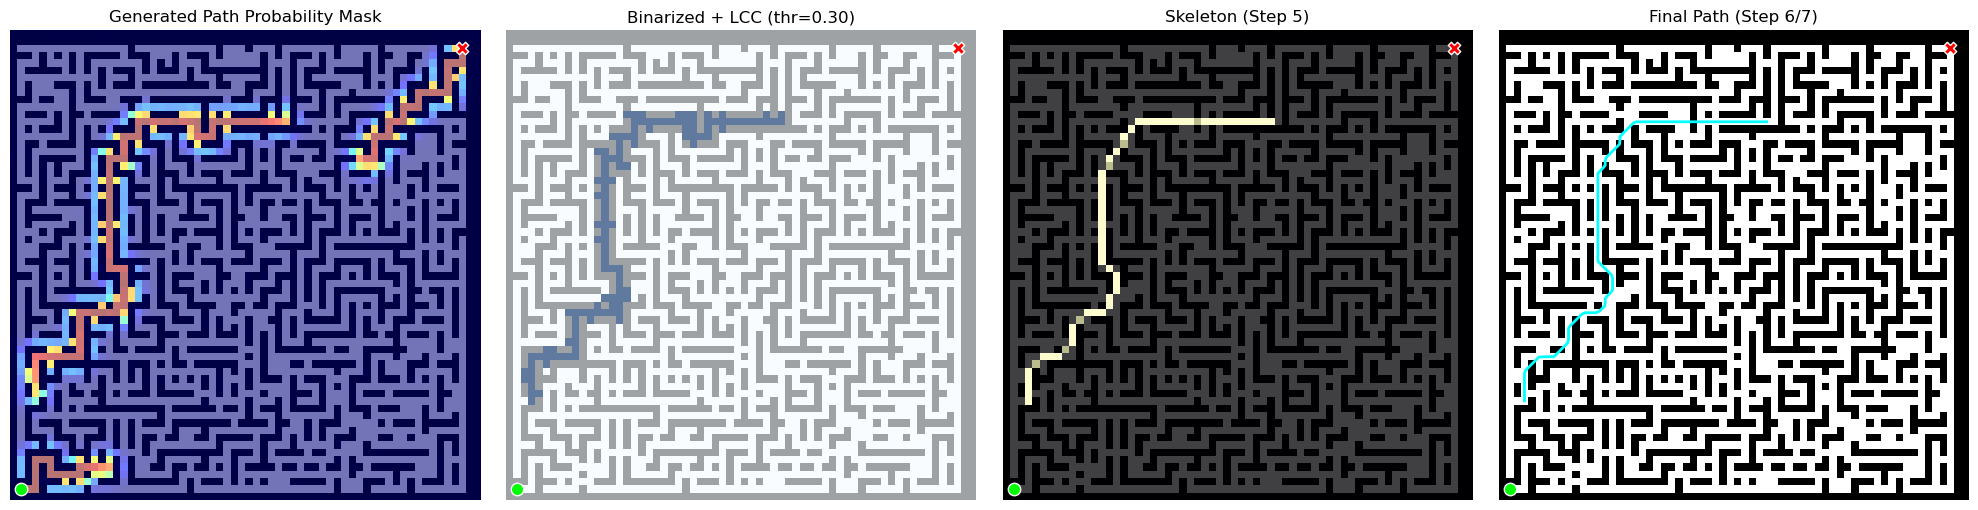

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label, binary_closing, binary_dilation
from skimage.morphology import skeletonize
from collections import deque

# --- 1. 超參數設定 (Image DDPM + Step 4~7) ---
IMG_SIZE = 64
N_STEPS = 100
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TIME_EMBED_DIM = 128
START_GOAL_SIGMA = 1.5
PATH_BRUSH_SIGMA = 1.2
THRESHOLD = 0.45
THR_CANDIDATES = np.arange(0.30, 0.61, 0.05)
USE_LARGEST_CC = True
SKELETON_PRE_CLOSING = 1
SKELETON_PRE_DILATION = 0
PATH_LENGTH = 128


# --- 2. 擴散排程 (DDPM, epsilon parameterization) ---
betas = torch.linspace(1e-4, 2e-2, N_STEPS, dtype=torch.float32, device=DEVICE)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)


def extract(a, t, x_shape):
    out = a.gather(0, t)
    return out.view(-1, *([1] * (len(x_shape) - 1)))


def q_sample(x0, t, noise):
    sqrt_alpha_bar_t = extract(sqrt_alphas_cumprod, t, x0.shape)
    sqrt_one_minus_alpha_bar_t = extract(sqrt_one_minus_alphas_cumprod, t, x0.shape)
    return sqrt_alpha_bar_t * x0 + sqrt_one_minus_alpha_bar_t * noise


def sinusoidal_time_embedding(t, dim):
    half_dim = dim // 2
    exponent = -np.log(10000.0) / max(half_dim - 1, 1)
    frequencies = torch.exp(torch.arange(half_dim, device=t.device, dtype=torch.float32) * exponent)
    args = t.float().unsqueeze(1) * frequencies.unsqueeze(0)
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)
    if dim % 2 == 1:
        emb = F.pad(emb, (0, 1))
    return emb


def _pick_gn_groups(num_channels, max_groups=8):
    for g in range(max_groups, 0, -1):
        if num_channels % g == 0:
            return g
    return 1


class ResBlock2D(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        g1 = _pick_gn_groups(out_ch)
        g2 = _pick_gn_groups(out_ch)

        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(g1, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(g2, out_ch)
        self.act = nn.Mish()

        self.time_proj = nn.Linear(time_dim, out_ch)
        self.res_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = self.norm1(h)

        time_bias = self.time_proj(t_emb).unsqueeze(-1).unsqueeze(-1)
        h = h + time_bias
        h = self.act(h)

        h = self.conv2(h)
        h = self.norm2(h)
        h = self.act(h)

        return h + self.res_conv(x)


class PathUNet2D(nn.Module):
    # input = concat(x_t[1ch], cond[3ch]) => 4ch
    # output = eps_pred[1ch]
    def __init__(self, time_embed_dim=TIME_EMBED_DIM):
        super().__init__()

        self.time_embed_dim = time_embed_dim
        self.time_mlp = nn.Sequential(
            nn.Linear(time_embed_dim, 128),
            nn.Mish(),
            nn.Linear(128, 128),
        )

        self.in_block = ResBlock2D(4, 64, 128)
        self.down1 = nn.Conv2d(64, 64, 4, stride=2, padding=1)   # 64->32

        self.down_block = ResBlock2D(64, 128, 128)
        self.down2 = nn.Conv2d(128, 128, 4, stride=2, padding=1) # 32->16

        self.mid_block = ResBlock2D(128, 128, 128)

        self.up2 = nn.ConvTranspose2d(128, 128, 4, stride=2, padding=1)   # 16->32
        self.up_block2 = ResBlock2D(128 + 128, 64, 128)

        self.up1 = nn.ConvTranspose2d(64, 64, 4, stride=2, padding=1)     # 32->64
        self.up_block1 = ResBlock2D(64 + 64, 64, 128)

        self.out_conv = nn.Conv2d(64, 1, 1)

    def forward(self, x_t, t, cond):
        model_input = torch.cat([x_t, cond], dim=1)  # [B,4,64,64]
        t_emb = sinusoidal_time_embedding(t, self.time_embed_dim)
        t_emb = self.time_mlp(t_emb)

        h1 = self.in_block(model_input, t_emb)
        d1 = self.down1(h1)

        h2 = self.down_block(d1, t_emb)
        d2 = self.down2(h2)

        mid = self.mid_block(d2, t_emb)

        u2 = self.up2(mid)
        u2 = self.up_block2(torch.cat([u2, h2], dim=1), t_emb)

        u1 = self.up1(u2)
        u1 = self.up_block1(torch.cat([u1, h1], dim=1), t_emb)

        return self.out_conv(u1)


# --- 3. 訓練設定 (predict epsilon) ---
denoise_model = PathUNet2D().to(DEVICE)
optimizer = torch.optim.Adam(denoise_model.parameters(), lr=1e-4)


def p_loss(x0, cond):
    b = x0.shape[0]
    t = torch.randint(0, N_STEPS, (b,), device=DEVICE)
    noise = torch.randn_like(x0)

    x_t = q_sample(x0, t, noise)
    noise_pred = denoise_model(x_t, t, cond)

    return F.mse_loss(noise_pred, noise)


def p_sample(x_t, t, cond):
    eps_theta = denoise_model(x_t, t, cond)

    beta_t = extract(betas, t, x_t.shape)
    sqrt_one_minus_alpha_bar_t = extract(sqrt_one_minus_alphas_cumprod, t, x_t.shape)
    sqrt_recip_alpha_t = extract(sqrt_recip_alphas, t, x_t.shape)

    model_mean = sqrt_recip_alpha_t * (x_t - (beta_t / sqrt_one_minus_alpha_bar_t) * eps_theta)

    if t[0].item() == 0:
        return model_mean

    posterior_var_t = extract(posterior_variance, t, x_t.shape)
    noise = torch.randn_like(x_t)
    return model_mean + torch.sqrt(posterior_var_t) * noise


def generate_path_mask(cond_tensor):
    # cond_tensor: [1,3,64,64]
    x_gen = torch.randn(1, 1, IMG_SIZE, IMG_SIZE, device=DEVICE)
    cond_tensor = cond_tensor.to(DEVICE)

    denoise_model.eval()
    with torch.no_grad():
        for i in range(N_STEPS - 1, -1, -1):
            t = torch.full((1,), i, dtype=torch.long, device=DEVICE)
            x_gen = p_sample(x_gen, t, cond_tensor)

    x0_gen = x_gen.squeeze(0).squeeze(0)  # [64,64]
    x0_gen = x0_gen.clamp(0.0, 1.0)
    return x0_gen


# --- 4. Step 4 Postprocess: threshold + largest CC ---
def keep_largest_connected_component(mask_bin):
    mask_bool = mask_bin.astype(bool)
    labeled, num = label(mask_bool)
    if num == 0:
        return mask_bin.astype(np.float32)

    sizes = np.bincount(labeled.ravel())
    sizes[0] = 0
    largest_label = sizes.argmax()
    return (labeled == largest_label).astype(np.float32)


def postprocess_mask(prob_mask, thr=0.45, use_lcc=True):
    mask_bin = (prob_mask > thr).astype(np.float32)
    if use_lcc:
        mask_bin = keep_largest_connected_component(mask_bin)
    return mask_bin


def iou_score(mask_a, mask_b, eps=1e-6):
    a = mask_a.astype(bool)
    b = mask_b.astype(bool)
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return float(inter) / float(union + eps)


def build_soft_mask_from_item(item, map_size=64, path_sigma=1.2):
    occ = item['map'].astype(np.float32)
    smooth_path = np.asarray(item['smooth_path'], dtype=np.float32)
    smooth_path = np.clip(smooth_path, 0.0, float(map_size - 1))

    gt_mask = np.zeros((map_size, map_size), dtype=np.float32)
    for r, c in smooth_path:
        add_gaussian_brush(gt_mask, float(r), float(c), sigma=path_sigma)

    gt_mask = np.clip(gt_mask, 0.0, 1.0)
    gt_mask = gt_mask * (1.0 - occ)
    return gt_mask


def sweep_threshold(prob_mask, gt_mask, thr_values=THR_CANDIDATES, use_lcc=True):
    best_thr = thr_values[0]
    best_iou = -1.0
    records = []

    for thr in thr_values:
        pred_bin = postprocess_mask(prob_mask, thr=thr, use_lcc=use_lcc)
        score = iou_score(pred_bin, gt_mask > 0.5)
        records.append((float(thr), float(score)))
        if score > best_iou:
            best_iou = score
            best_thr = float(thr)

    return best_thr, best_iou, records


def build_cond_from_item(item, map_size=64, sigma=1.5):
    occ = item['map'].astype(np.float32)
    start_hm = gaussian_heatmap((map_size, map_size), item['start'], sigma=sigma)
    goal_hm = gaussian_heatmap((map_size, map_size), item['goal'], sigma=sigma)
    cond = np.stack([occ, start_hm, goal_hm], axis=0).astype(np.float32)
    return torch.from_numpy(cond).unsqueeze(0)  # [1,3,64,64]


# --- 5. Step 5/6/7: skeletonize + shortest path + output format ---
def skeletonize_mask(mask_bin, closing_iter=1, dilation_iter=0):
    mask = mask_bin.astype(bool)

    if dilation_iter > 0:
        for _ in range(dilation_iter):
            mask = binary_dilation(mask)

    if closing_iter > 0:
        for _ in range(closing_iter):
            mask = binary_closing(mask)

    skel = skeletonize(mask)
    return skel


def nearest_skeleton_pixel(skel, point_rc):
    coords = np.argwhere(skel)
    if len(coords) == 0:
        return None

    p = np.array(point_rc, dtype=np.float32)
    d2 = ((coords.astype(np.float32) - p[None, :]) ** 2).sum(axis=1)
    idx = int(np.argmin(d2))
    return tuple(coords[idx].tolist())


def shortest_path_on_skeleton(skel, start_rc, goal_rc):
    start_node = nearest_skeleton_pixel(skel, start_rc)
    goal_node = nearest_skeleton_pixel(skel, goal_rc)

    if start_node is None or goal_node is None:
        return None

    if start_node == goal_node:
        return [start_node]

    h, w = skel.shape
    neighbors = [
        (-1, -1), (-1, 0), (-1, 1),
        (0, -1),           (0, 1),
        (1, -1),  (1, 0),  (1, 1),
    ]

    queue = deque([start_node])
    visited = set([start_node])
    parent = {}

    found = False
    while queue:
        cur = queue.popleft()
        if cur == goal_node:
            found = True
            break

        for dr, dc in neighbors:
            nr, nc = cur[0] + dr, cur[1] + dc
            nxt = (nr, nc)
            if nr < 0 or nr >= h or nc < 0 or nc >= w:
                continue
            if not skel[nr, nc]:
                continue
            if nxt in visited:
                continue
            visited.add(nxt)
            parent[nxt] = cur
            queue.append(nxt)

    if not found:
        return None

    path = [goal_node]
    while path[-1] != start_node:
        path.append(parent[path[-1]])
    path.reverse()
    return path


def resample_path(path_rc, n_points=128):
    path = np.asarray(path_rc, dtype=np.float32)
    if len(path) == 0:
        return path
    if len(path) == 1:
        return np.repeat(path, n_points, axis=0)

    seg = np.diff(path, axis=0)
    seg_len = np.linalg.norm(seg, axis=1)
    cum_len = np.concatenate([[0.0], np.cumsum(seg_len)])
    total = float(cum_len[-1])

    if total < 1e-8:
        return np.repeat(path[:1], n_points, axis=0)

    samples = np.linspace(0.0, total, n_points)
    rows = np.interp(samples, cum_len, path[:, 0])
    cols = np.interp(samples, cum_len, path[:, 1])
    return np.stack([rows, cols], axis=1)


def extract_final_path(mask_bin, start_rc, goal_rc, closing_iter=1, dilation_iter=0, path_length=128):
    skel = skeletonize_mask(mask_bin, closing_iter=closing_iter, dilation_iter=dilation_iter)
    raw_path = shortest_path_on_skeleton(skel, start_rc, goal_rc)

    if raw_path is None:
        return skel, None, None

    raw_path = np.asarray(raw_path, dtype=np.float32)
    final_path = resample_path(raw_path, n_points=path_length)
    return skel, raw_path, final_path


# --- 6. 執行訓練 (using mask_loader from Step 0~2) ---
n_epochs = 200
print(f"Training on {DEVICE}, epochs={n_epochs}")

for epoch in range(n_epochs):
    denoise_model.train()
    epoch_loss = 0.0

    for batch_x0, batch_cond in mask_loader:
        batch_x0 = batch_x0.to(DEVICE)      # [B,1,64,64]
        batch_cond = batch_cond.to(DEVICE)  # [B,3,64,64]

        optimizer.zero_grad()
        loss = p_loss(batch_x0, batch_cond)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Loss: {epoch_loss / len(mask_loader):.6f}")


# --- 7. 快速測試 (Map_0): Step 4 + 5 + 6 + 7 ---
test_data = map_dictionary['Map_0']
test_cond = build_cond_from_item(test_data, map_size=IMG_SIZE, sigma=START_GOAL_SIGMA)

prob_mask = generate_path_mask(test_cond).detach().cpu().numpy()      # [64,64]
gt_soft_mask = build_soft_mask_from_item(test_data, map_size=IMG_SIZE, path_sigma=PATH_BRUSH_SIGMA)

best_thr, best_iou, thr_records = sweep_threshold(
    prob_mask,
    gt_soft_mask,
    thr_values=THR_CANDIDATES,
    use_lcc=USE_LARGEST_CC,
)
AUTO_THRESHOLD = best_thr
mask_bin = postprocess_mask(prob_mask, thr=AUTO_THRESHOLD, use_lcc=USE_LARGEST_CC)

skel, raw_path, final_path = extract_final_path(
    mask_bin,
    test_data['start'],
    test_data['goal'],
    closing_iter=SKELETON_PRE_CLOSING,
    dilation_iter=SKELETON_PRE_DILATION,
    path_length=PATH_LENGTH,
)

path_ok = final_path is not None
print(f"Step 4 selected threshold: {AUTO_THRESHOLD:.2f} (IoU={best_iou:.4f}, use_lcc={USE_LARGEST_CC})")
print("Sweep scores:", thr_records)
print(f"Step 6 path found: {path_ok}")
if path_ok:
    print(f"Raw path points: {len(raw_path)} | Resampled path points: {len(final_path)}")

plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.imshow(test_data['map'], cmap='Greys', origin='lower')
plt.imshow(prob_mask, cmap='jet', alpha=0.55, origin='lower')
plt.scatter(test_data['start'][1], test_data['start'][0], c='lime', s=80, marker='o', edgecolors='white')
plt.scatter(test_data['goal'][1], test_data['goal'][0], c='red', s=80, marker='X', edgecolors='white')
plt.title('Generated Path Probability Mask')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(test_data['map'], cmap='Greys', origin='lower')
plt.imshow(mask_bin, cmap='Blues', alpha=0.65, origin='lower')
plt.scatter(test_data['start'][1], test_data['start'][0], c='lime', s=80, marker='o', edgecolors='white')
plt.scatter(test_data['goal'][1], test_data['goal'][0], c='red', s=80, marker='X', edgecolors='white')
plt.title(f'Binarized + LCC (thr={AUTO_THRESHOLD:.2f})')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(test_data['map'], cmap='Greys', origin='lower')
plt.imshow(skel.astype(np.float32), cmap='magma', alpha=0.75, origin='lower')
plt.scatter(test_data['start'][1], test_data['start'][0], c='lime', s=80, marker='o', edgecolors='white')
plt.scatter(test_data['goal'][1], test_data['goal'][0], c='red', s=80, marker='X', edgecolors='white')
plt.title('Skeleton (Step 5)')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(test_data['map'], cmap='Greys', origin='lower')
if path_ok:
    plt.plot(final_path[:, 1], final_path[:, 0], color='cyan', linewidth=2)
    plt.title('Final Path (Step 6/7)')
else:
    plt.title('No valid skeleton path found')
plt.scatter(test_data['start'][1], test_data['start'][0], c='lime', s=80, marker='o', edgecolors='white')
plt.scatter(test_data['goal'][1], test_data['goal'][0], c='red', s=80, marker='X', edgecolors='white')
plt.axis('off')

plt.tight_layout()
plt.show()

Step 4 selected threshold: 0.40 (IoU=0.5159, use_lcc=True)
Sweep scores: [(0.3, 0.515748029465559), (0.35, 0.515748029465559), (0.39999999999999997, 0.5158730138259008), (0.44999999999999996, 0.5139442210599832), (0.49999999999999994, 0.5100401585942163), (0.5499999999999999, 0.5060240943533169), (0.5999999999999999, 0.5060240943533169)]
Step 6 path found: True
Raw path points: 87 | Resampled path points: 128


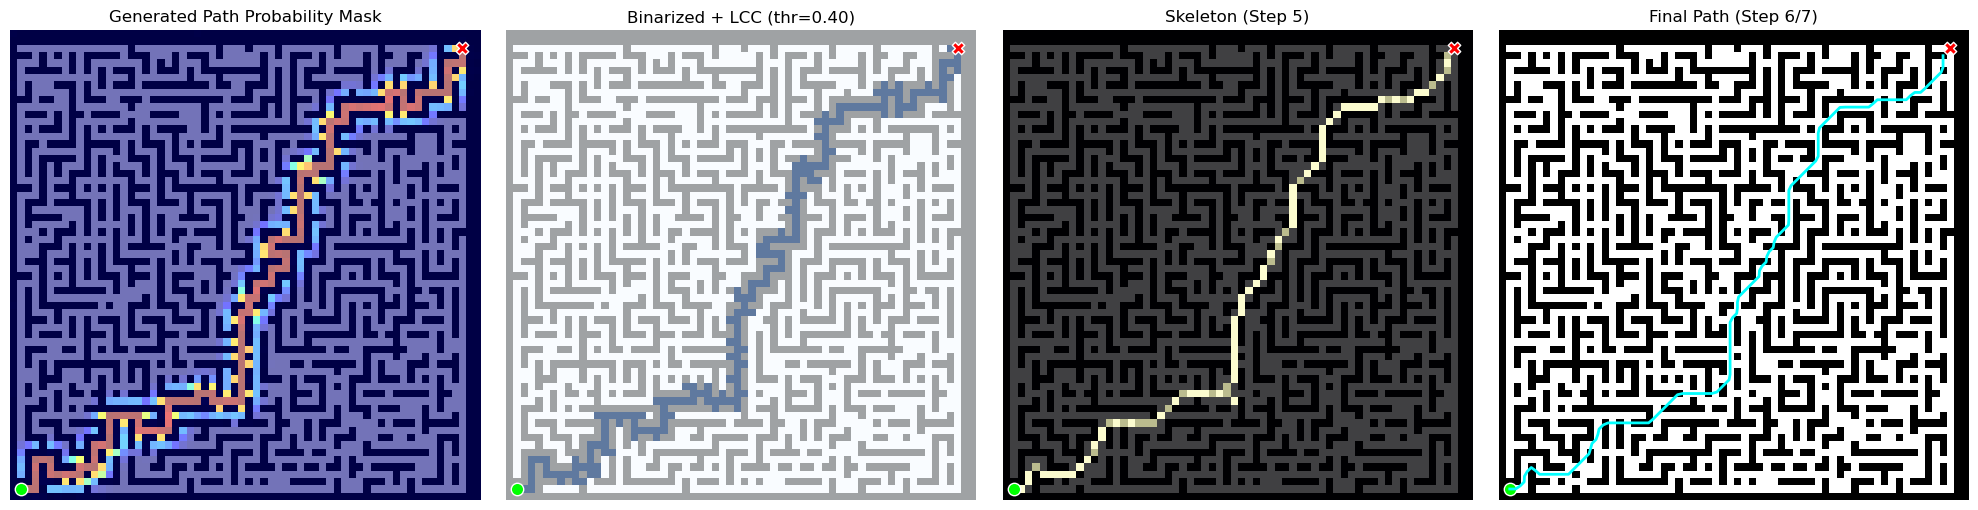

In [8]:
# --- 7. 快速測試 (Map_0): Step 4 + 5 + 6 + 7 ---
test_data = map_dictionary['Map_0']
test_cond = build_cond_from_item(test_data, map_size=IMG_SIZE, sigma=START_GOAL_SIGMA)

prob_mask = generate_path_mask(test_cond).detach().cpu().numpy()      # [64,64]
gt_soft_mask = build_soft_mask_from_item(test_data, map_size=IMG_SIZE, path_sigma=PATH_BRUSH_SIGMA)

best_thr, best_iou, thr_records = sweep_threshold(
    prob_mask,
    gt_soft_mask,
    thr_values=THR_CANDIDATES,
    use_lcc=USE_LARGEST_CC,
)
AUTO_THRESHOLD = best_thr
mask_bin = postprocess_mask(prob_mask, thr=AUTO_THRESHOLD, use_lcc=USE_LARGEST_CC)

skel, raw_path, final_path = extract_final_path(
    mask_bin,
    test_data['start'],
    test_data['goal'],
    closing_iter=SKELETON_PRE_CLOSING,
    dilation_iter=SKELETON_PRE_DILATION,
    path_length=PATH_LENGTH,
)

path_ok = final_path is not None
print(f"Step 4 selected threshold: {AUTO_THRESHOLD:.2f} (IoU={best_iou:.4f}, use_lcc={USE_LARGEST_CC})")
print("Sweep scores:", thr_records)
print(f"Step 6 path found: {path_ok}")
if path_ok:
    print(f"Raw path points: {len(raw_path)} | Resampled path points: {len(final_path)}")

plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.imshow(test_data['map'], cmap='Greys', origin='lower')
plt.imshow(prob_mask, cmap='jet', alpha=0.55, origin='lower')
plt.scatter(test_data['start'][1], test_data['start'][0], c='lime', s=80, marker='o', edgecolors='white')
plt.scatter(test_data['goal'][1], test_data['goal'][0], c='red', s=80, marker='X', edgecolors='white')
plt.title('Generated Path Probability Mask')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(test_data['map'], cmap='Greys', origin='lower')
plt.imshow(mask_bin, cmap='Blues', alpha=0.65, origin='lower')
plt.scatter(test_data['start'][1], test_data['start'][0], c='lime', s=80, marker='o', edgecolors='white')
plt.scatter(test_data['goal'][1], test_data['goal'][0], c='red', s=80, marker='X', edgecolors='white')
plt.title(f'Binarized + LCC (thr={AUTO_THRESHOLD:.2f})')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(test_data['map'], cmap='Greys', origin='lower')
plt.imshow(skel.astype(np.float32), cmap='magma', alpha=0.75, origin='lower')
plt.scatter(test_data['start'][1], test_data['start'][0], c='lime', s=80, marker='o', edgecolors='white')
plt.scatter(test_data['goal'][1], test_data['goal'][0], c='red', s=80, marker='X', edgecolors='white')
plt.title('Skeleton (Step 5)')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(test_data['map'], cmap='Greys', origin='lower')
if path_ok:
    plt.plot(final_path[:, 1], final_path[:, 0], color='cyan', linewidth=2)
    plt.title('Final Path (Step 6/7)')
else:
    plt.title('No valid skeleton path found')
plt.scatter(test_data['start'][1], test_data['start'][0], c='lime', s=80, marker='o', edgecolors='white')
plt.scatter(test_data['goal'][1], test_data['goal'][0], c='red', s=80, marker='X', edgecolors='white')
plt.axis('off')

plt.tight_layout()
plt.show()

Unseen map threshold=0.40, use_lcc=True
Step 6 path found: True
Raw path points: 65 | Resampled path points: 128
Final output format: (row, col), shape=(128, 2)


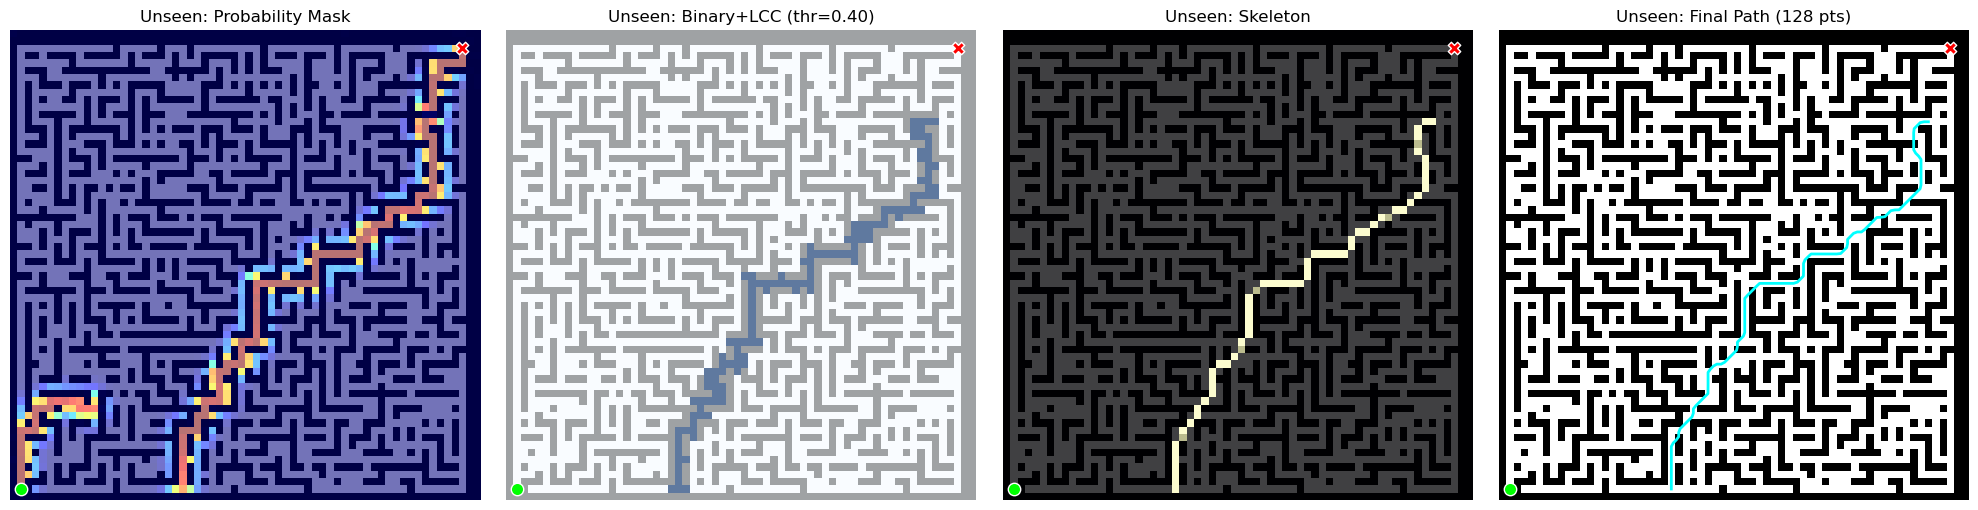

In [12]:
# 1. 產生一張完全陌生的地圖 (Unseen Map)
# test_grid, test_start, test_goal = generate_map(size=64)


# Change these lines in Cell 5:
test_grid, test_start, test_goal = generate_map(size=IMG_SIZE, multiplier=1)

start_hm = gaussian_heatmap(test_grid.shape, test_start, sigma=START_GOAL_SIGMA)
goal_hm = gaussian_heatmap(test_grid.shape, test_goal, sigma=START_GOAL_SIGMA)

# 2. 建立 3-channel condition: [occ, start_hm, goal_hm]
occ = test_grid.astype(np.float32)
# start_hm = gaussian_heatmap((64, 64), test_start, sigma=START_GOAL_SIGMA)
# goal_hm = gaussian_heatmap((64, 64), test_goal, sigma=START_GOAL_SIGMA)
cond = np.stack([occ, start_hm, goal_hm], axis=0).astype(np.float32)
test_cond = torch.from_numpy(cond).unsqueeze(0)  # [1,3,64,64]

# 3. Diffusion 生成 path probability mask
denoise_model.eval()
with torch.no_grad():
    prob_mask = generate_path_mask(test_cond).cpu().numpy()  # [64,64]

# 4. Step 4 postprocess: threshold + largest CC
thr_to_use = AUTO_THRESHOLD if 'AUTO_THRESHOLD' in globals() else THRESHOLD
mask_bin = postprocess_mask(prob_mask, thr=thr_to_use, use_lcc=USE_LARGEST_CC)

# 5/6/7: skeletonize -> shortest path on skeleton -> resample to fixed length
skel, raw_path, final_path = extract_final_path(
    mask_bin,
    test_start,
    test_goal,
    closing_iter=SKELETON_PRE_CLOSING,
    dilation_iter=SKELETON_PRE_DILATION,
    path_length=PATH_LENGTH,
)

path_ok = final_path is not None
print(f"Unseen map threshold={thr_to_use:.2f}, use_lcc={USE_LARGEST_CC}")
print(f"Step 6 path found: {path_ok}")
if path_ok:
    print(f"Raw path points: {len(raw_path)} | Resampled path points: {len(final_path)}")
    print(f"Final output format: (row, col), shape={final_path.shape}")

# 6. 視覺化結果
plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.imshow(test_grid, cmap='Greys', origin='lower')
plt.imshow(prob_mask, cmap='jet', alpha=0.55, origin='lower')
plt.scatter(test_start[1], test_start[0], c='lime', s=80, marker='o', edgecolors='white')
plt.scatter(test_goal[1], test_goal[0], c='red', s=80, marker='X', edgecolors='white')
plt.title('Unseen: Probability Mask')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(test_grid, cmap='Greys', origin='lower')
plt.imshow(mask_bin, cmap='Blues', alpha=0.65, origin='lower')
plt.scatter(test_start[1], test_start[0], c='lime', s=80, marker='o', edgecolors='white')
plt.scatter(test_goal[1], test_goal[0], c='red', s=80, marker='X', edgecolors='white')
plt.title(f'Unseen: Binary+LCC (thr={thr_to_use:.2f})')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(test_grid, cmap='Greys', origin='lower')
plt.imshow(skel.astype(np.float32), cmap='magma', alpha=0.75, origin='lower')
plt.scatter(test_start[1], test_start[0], c='lime', s=80, marker='o', edgecolors='white')
plt.scatter(test_goal[1], test_goal[0], c='red', s=80, marker='X', edgecolors='white')
plt.title('Unseen: Skeleton')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(test_grid, cmap='Greys', origin='lower')
if path_ok:
    plt.plot(final_path[:, 1], final_path[:, 0], color='cyan', linewidth=2)
    plt.title(f'Unseen: Final Path ({PATH_LENGTH} pts)')
else:
    plt.title('Unseen: No valid path')
plt.scatter(test_start[1], test_start[0], c='lime', s=80, marker='o', edgecolors='white')
plt.scatter(test_goal[1], test_goal[0], c='red', s=80, marker='X', edgecolors='white')
plt.axis('off')

plt.tight_layout()
plt.show()

# final_path 即 Step 7 輸出: ndarray, shape [PATH_LENGTH, 2], each row=(row, col)

Running Step 8 evaluation on 100 unseen maps | threshold=0.60

===== Step 8 Summary =====
Path found rate          : 1.000
Connected rate           : 0.090  (endpoint <= 3.0px)
Avg collision rate       : 0.116
Avg path length (pixels) : 57.95
Avg start endpoint error : 18.96
Avg goal endpoint error  : 21.84
Threshold sensitivity    : fixed_ok=100/100, best_thr_ok=100/100


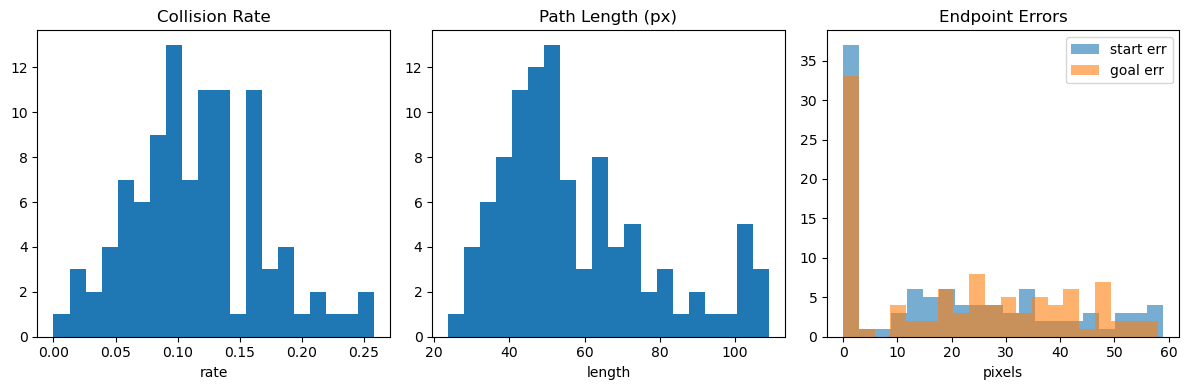

In [7]:
# --- Step 8: Evaluation on unseen maps ---
# Metrics: success/connectivity, collision, path length, endpoint error, threshold sensitivity

EVAL_MAPS = 100
OBSTACLE_PROB = 0.2
END_DIST_THR = 3.0  # pixels


def path_collision_rate(path_rc, occ_grid):
    if path_rc is None or len(path_rc) == 0:
        return np.nan

    h, w = occ_grid.shape
    rr = np.clip(np.round(path_rc[:, 0]).astype(int), 0, h - 1)
    cc = np.clip(np.round(path_rc[:, 1]).astype(int), 0, w - 1)

    collided = occ_grid[rr, cc] > 0.5
    return float(collided.mean())


def path_length_pixels(path_rc):
    if path_rc is None or len(path_rc) < 2:
        return np.nan
    seg = np.diff(path_rc, axis=0)
    return float(np.linalg.norm(seg, axis=1).sum())


def endpoint_errors(path_rc, start_rc, goal_rc):
    if path_rc is None or len(path_rc) == 0:
        return np.nan, np.nan
    p0 = path_rc[0]
    p1 = path_rc[-1]
    e_start = float(np.linalg.norm(p0 - np.array(start_rc, dtype=np.float32)))
    e_goal = float(np.linalg.norm(p1 - np.array(goal_rc, dtype=np.float32)))
    return e_start, e_goal


def evaluate_one_map(grid, start, goal, threshold, use_lcc=True):
    cond = np.stack([
        grid.astype(np.float32),
        gaussian_heatmap((IMG_SIZE, IMG_SIZE), start, sigma=START_GOAL_SIGMA),
        gaussian_heatmap((IMG_SIZE, IMG_SIZE), goal, sigma=START_GOAL_SIGMA),
    ], axis=0).astype(np.float32)
    cond_tensor = torch.from_numpy(cond).unsqueeze(0)

    with torch.no_grad():
        prob_mask = generate_path_mask(cond_tensor).cpu().numpy()

    mask_bin = postprocess_mask(prob_mask, thr=threshold, use_lcc=use_lcc)
    skel, raw_path, final_path = extract_final_path(
        mask_bin,
        start,
        goal,
        closing_iter=SKELETON_PRE_CLOSING,
        dilation_iter=SKELETON_PRE_DILATION,
        path_length=PATH_LENGTH,
    )

    ok = final_path is not None
    coll = path_collision_rate(final_path, grid)
    plen = path_length_pixels(final_path)
    e_start, e_goal = endpoint_errors(final_path, start, goal)

    connected = bool(ok and e_start <= END_DIST_THR and e_goal <= END_DIST_THR)

    return {
        'ok': ok,
        'connected': connected,
        'collision_rate': coll,
        'path_length': plen,
        'endpoint_start_err': e_start,
        'endpoint_goal_err': e_goal,
        'prob_mask': prob_mask,
        'mask_bin': mask_bin,
        'skel': skel,
        'final_path': final_path,
    }


thr_eval = AUTO_THRESHOLD if 'AUTO_THRESHOLD' in globals() else THRESHOLD
print(f"Running Step 8 evaluation on {EVAL_MAPS} unseen maps | threshold={thr_eval:.2f}")

ok_list = []
connected_list = []
coll_list = []
len_list = []
start_err_list = []
goal_err_list = []

# threshold sensitivity: fixed threshold vs per-map best threshold
fixed_ok = 0
best_ok = 0

for i in range(EVAL_MAPS):
    grid, start, goal = generate_map(size=IMG_SIZE)

    # fixed-threshold evaluation
    out_fixed = evaluate_one_map(grid, start, goal, threshold=thr_eval, use_lcc=USE_LARGEST_CC)
    ok_list.append(out_fixed['ok'])
    connected_list.append(out_fixed['connected'])
    coll_list.append(out_fixed['collision_rate'])
    len_list.append(out_fixed['path_length'])
    start_err_list.append(out_fixed['endpoint_start_err'])
    goal_err_list.append(out_fixed['endpoint_goal_err'])

    fixed_ok += int(out_fixed['ok'])

    # per-map threshold best (using soft GT from A*+smooth as reference)
    # if no A* path exists, fallback to fixed threshold counting
    path = a_star(grid, start, goal)
    if path is not None and len(path) >= 4:
        smooth = B_spline(path, s=1, k=3, num_points=128)
        item_tmp = {'map': grid, 'start': start, 'goal': goal, 'smooth_path': smooth}
        gt_soft = build_soft_mask_from_item(item_tmp, map_size=IMG_SIZE, path_sigma=PATH_BRUSH_SIGMA)
        best_thr, _, _ = sweep_threshold(out_fixed['prob_mask'], gt_soft, thr_values=THR_CANDIDATES, use_lcc=USE_LARGEST_CC)
        out_best = evaluate_one_map(grid, start, goal, threshold=best_thr, use_lcc=USE_LARGEST_CC)
        best_ok += int(out_best['ok'])
    else:
        best_ok += int(out_fixed['ok'])

ok_arr = np.array(ok_list, dtype=np.float32)
connected_arr = np.array(connected_list, dtype=np.float32)
coll_arr = np.array([x for x in coll_list if not np.isnan(x)], dtype=np.float32)
len_arr = np.array([x for x in len_list if not np.isnan(x)], dtype=np.float32)
se_arr = np.array([x for x in start_err_list if not np.isnan(x)], dtype=np.float32)
ge_arr = np.array([x for x in goal_err_list if not np.isnan(x)], dtype=np.float32)

print("\n===== Step 8 Summary =====")
print(f"Path found rate          : {ok_arr.mean():.3f}")
print(f"Connected rate           : {connected_arr.mean():.3f}  (endpoint <= {END_DIST_THR}px)")
print(f"Avg collision rate       : {coll_arr.mean() if len(coll_arr)>0 else np.nan:.3f}")
print(f"Avg path length (pixels) : {len_arr.mean() if len(len_arr)>0 else np.nan:.2f}")
print(f"Avg start endpoint error : {se_arr.mean() if len(se_arr)>0 else np.nan:.2f}")
print(f"Avg goal endpoint error  : {ge_arr.mean() if len(ge_arr)>0 else np.nan:.2f}")
print(f"Threshold sensitivity    : fixed_ok={fixed_ok}/{EVAL_MAPS}, best_thr_ok={best_ok}/{EVAL_MAPS}")

# quick visualization for metric distributions
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
if len(coll_arr) > 0:
    plt.hist(coll_arr, bins=20)
plt.title('Collision Rate')
plt.xlabel('rate')

plt.subplot(1, 3, 2)
if len(len_arr) > 0:
    plt.hist(len_arr, bins=20)
plt.title('Path Length (px)')
plt.xlabel('length')

plt.subplot(1, 3, 3)
if len(se_arr) > 0 and len(ge_arr) > 0:
    plt.hist(se_arr, bins=20, alpha=0.6, label='start err')
    plt.hist(ge_arr, bins=20, alpha=0.6, label='goal err')
    plt.legend()
plt.title('Endpoint Errors')
plt.xlabel('pixels')

plt.tight_layout()
plt.show()